In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
recipes_path = "../../datasets/RAW_recipes.csv"

recipes = pd.read_csv(recipes_path)

print("Recipes dataset successfully loaded.")

Recipes dataset successfully loaded.


In [4]:
interactions_path = "../../datasets/RAW_interactions.csv"

interactions = pd.read_csv(interactions_path)

print("Interactions dataset successfully loaded.")

Interactions dataset successfully loaded.


In [5]:
print("Recipes shape:", recipes.shape)
print("Interactions shape:", interactions.shape)

print(interactions.head())
print(recipes.head())

print(interactions.columns.tolist())
print(recipes.columns.tolist())

Recipes shape: (231637, 12)
Interactions shape: (1132367, 5)
   user_id  recipe_id        date  rating  \
0    38094      40893  2003-02-17       4   
1  1293707      40893  2011-12-21       5   
2     8937      44394  2002-12-01       4   
3   126440      85009  2010-02-27       5   
4    57222      85009  2011-10-01       5   

                                              review  
0  Great with a salad. Cooked on top of stove for...  
1  So simple, so delicious! Great for chilly fall...  
2  This worked very well and is EASY.  I used not...  
3  I made the Mexican topping and took it to bunk...  
4  Made the cheddar bacon topping, adding a sprin...  
                                         name      id  minutes  \
0  arriba   baked winter squash mexican style  137739       55   
1            a bit different  breakfast pizza   31490       30   
2                   all in the kitchen  chili  112140      130   
3                          alouette  potatoes   59389       45   
4       

In [6]:
interactions["rating"].value_counts().sort_index()

rating
0     60847
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64

In [7]:
interactions["rating"].describe()

count    1.132367e+06
mean     4.411016e+00
std      1.264752e+00
min      0.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

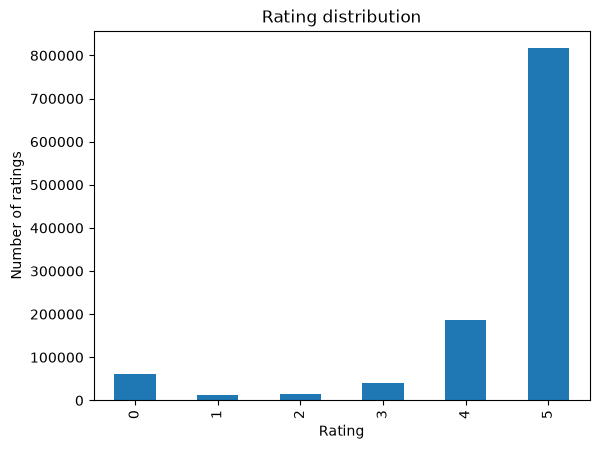

In [8]:
import matplotlib.pyplot as plt

interactions["rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Rating")
plt.ylabel("Number of ratings")
plt.title("Rating distribution")
plt.show()

In [9]:
duplicates = interactions.duplicated(
    subset=["user_id", "recipe_id"]
).sum()

print("Duplicate user-recipe pairs:", duplicates)

Duplicate user-recipe pairs: 0


In [10]:
user_counts = interactions["user_id"].value_counts()

print(user_counts.describe())

count    226570.000000
mean          4.997868
std          49.663111
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        7671.000000
Name: count, dtype: float64


In [11]:
recipe_counts = interactions["recipe_id"].value_counts()

print(recipe_counts.describe())

count    231637.000000
mean          4.888541
std          17.532481
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1613.000000
Name: count, dtype: float64


In [12]:
print("Users with only 1 rating:", (user_counts == 1).sum())
print("Users with 5 or fewer ratings:", (user_counts <= 5).sum())

print("Recipes with only 1 rating:", (recipe_counts == 1).sum())
print("Recipes with 5 or fewer ratings:", (recipe_counts <= 5).sum())

Users with only 1 rating: 166256
Users with 5 or fewer ratings: 206905
Recipes with only 1 rating: 91953
Recipes with 5 or fewer ratings: 188753


In [13]:
recipes["id"]

0         137739
1          31490
2         112140
3          59389
4          44061
           ...  
231632    486161
231633    493372
231634    308080
231635    298512
231636    298509
Name: id, Length: 231637, dtype: int64

In [14]:
interactions["recipe_id"]

0           40893
1           40893
2           44394
3           85009
4           85009
            ...  
1132362     72730
1132363    386618
1132364     78003
1132365     78003
1132366     78003
Name: recipe_id, Length: 1132367, dtype: int64

In [15]:
recipe_ids = set(recipes["id"])

missing_recipes = (
    ~interactions["recipe_id"].isin(recipe_ids)
).sum()

print("Interactions with missing recipes:", missing_recipes)

Interactions with missing recipes: 0


In [16]:
data = interactions[
    ["user_id", "recipe_id", "rating"]
].copy()

print(data.head())
print(data.shape)

   user_id  recipe_id  rating
0    38094      40893       4
1  1293707      40893       5
2     8937      44394       4
3   126440      85009       5
4    57222      85009       5
(1132367, 3)


In [17]:
data = data[data["rating"] > 0].copy()

print(data["rating"].value_counts().sort_index())

rating
1     12818
2     14123
3     40855
4    187360
5    816364
Name: count, dtype: int64


In [18]:
user_ids = data["user_id"].unique()
recipe_ids = data["recipe_id"].unique()

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

recipe_to_idx = {
    recipe_id: idx
    for idx, recipe_id in enumerate(recipe_ids)
}

In [19]:
data["user_idx"] = data["user_id"].map(user_to_idx)
data["recipe_idx"] = data["recipe_id"].map(recipe_to_idx)

In [20]:
data.head()

,user_id,recipe_id,rating,user_idx,recipe_idx
0,38094,40893,4,0,0
1,1293707,40893,5,1,0
2,8937,44394,4,2,1
3,126440,85009,5,3,2
4,57222,85009,5,4,2


In [21]:
num_users = len(user_to_idx)
num_recipes = len(recipe_to_idx)

print("Number of users:", num_users)
print("Number of recipes:", num_recipes)
print("Number of interactions:", len(data))

Number of users: 196098
Number of recipes: 226590
Number of interactions: 1071520


In [22]:
data = interactions[
    ["user_id", "recipe_id", "rating"]
].copy()

# Izbacujemo rating 0
data = data[data["rating"] > 0].copy()

print("Interactions after removing rating 0:", len(data))

Interactions after removing rating 0: 1071520


In [23]:
MIN_USER_RATINGS = 5
MIN_RECIPE_RATINGS = 5

while True:
    old_size = len(data)

    # Broj ratinga po korisniku
    user_counts = data["user_id"].value_counts()

    # Broj ratinga po receptu
    recipe_counts = data["recipe_id"].value_counts()

    # Zadrži samo korisnike sa >= 5 ratinga
    data = data[
        data["user_id"].isin(
            user_counts[user_counts >= MIN_USER_RATINGS].index
        )
    ]

    # Zadrži samo recepte sa >= 5 ratinga
    data = data[
        data["recipe_id"].isin(
            recipe_counts[recipe_counts >= MIN_RECIPE_RATINGS].index
        )
    ]

    # Ako se ništa više ne menja, završili smo
    if len(data) == old_size:
        break

print("Final interactions:", len(data))
print("Users:", data["user_id"].nunique())
print("Recipes:", data["recipe_id"].nunique())

Final interactions: 535047
Users: 17034
Recipes: 40027


In [24]:
user_counts = data["user_id"].value_counts()
recipe_counts = data["recipe_id"].value_counts()

print("Minimum user ratings:", user_counts.min())
print("Minimum recipe ratings:", recipe_counts.min())

print("\nUsers:")
print(user_counts.describe())

print("\nRecipes:")
print(recipe_counts.describe())

Minimum user ratings: 5
Minimum recipe ratings: 5

Users:
count    17034.000000
mean        31.410532
std         92.395144
min          5.000000
25%          6.000000
50%         10.000000
75%         23.000000
max       2779.000000
Name: count, dtype: float64

Recipes:
count    40027.000000
mean        13.367152
std         24.531410
min          5.000000
25%          6.000000
50%          8.000000
75%         12.000000
max        990.000000
Name: count, dtype: float64


In [25]:
print("Users with < 5 ratings:",
      (user_counts < 5).sum())

print("Recipes with < 5 ratings:",
      (recipe_counts < 5).sum())

Users with < 5 ratings: 0
Recipes with < 5 ratings: 0


In [26]:
print("Final interactions:", len(data))
print("Users:", data["user_id"].nunique())
print("Recipes:", data["recipe_id"].nunique())
print("Minimum user ratings:", user_counts.min())
print("Minimum recipe ratings:", recipe_counts.min())

Final interactions: 535047
Users: 17034
Recipes: 40027
Minimum user ratings: 5
Minimum recipe ratings: 5


In [27]:
data = interactions[
    ["user_id", "recipe_id", "rating", "date"]
].copy()

data = data[data["rating"] > 0].copy()

print(data.head())

   user_id  recipe_id  rating        date
0    38094      40893       4  2003-02-17
1  1293707      40893       5  2011-12-21
2     8937      44394       4  2002-12-01
3   126440      85009       5  2010-02-27
4    57222      85009       5  2011-10-01


In [28]:
data["date"] = pd.to_datetime(data["date"])

print(data["date"].min())
print(data["date"].max())

2000-01-25 00:00:00
2018-12-20 00:00:00


In [29]:
MIN_USER_RATINGS = 5
MIN_RECIPE_RATINGS = 5

while True:
    old_size = len(data)

    user_counts = data["user_id"].value_counts()
    recipe_counts = data["recipe_id"].value_counts()

    data = data[
        data["user_id"].isin(
            user_counts[user_counts >= MIN_USER_RATINGS].index
        )
    ]

    data = data[
        data["recipe_id"].isin(
            recipe_counts[recipe_counts >= MIN_RECIPE_RATINGS].index
        )
    ]

    if len(data) == old_size:
        break

print("Interactions:", len(data))
print("Users:", data["user_id"].nunique())
print("Recipes:", data["recipe_id"].nunique())

Interactions: 535047
Users: 17034
Recipes: 40027


In [30]:
data = data.sort_values("date").reset_index(drop=True)

In [31]:
data[["user_id", "recipe_id", "rating", "date"]].head(10)

,user_id,recipe_id,rating,date
0,2312,780,5,2000-09-12
1,2999,3567,5,2000-10-23
2,2178,3704,3,2000-10-30
3,2178,4366,5,2000-11-04
4,3794,191,5,2000-12-15
5,2695,4807,2,2000-12-27
6,2312,3651,5,2001-01-16
7,2695,12134,5,2001-01-19
8,5523,7695,1,2001-02-01
9,5523,2713,4,2001-02-01


In [32]:
data[["user_id", "recipe_id", "rating", "date"]].tail(10)

,user_id,recipe_id,rating,date
535037,218535,167834,5,2018-12-16
535038,2000498330,118122,5,2018-12-16
535039,146742,278872,5,2018-12-16
535040,218535,108068,5,2018-12-16
535041,2002025577,173518,5,2018-12-17
535042,2001513060,367414,1,2018-12-17
535043,527509,78552,2,2018-12-17
535044,2001513060,192495,5,2018-12-17
535045,226867,363072,5,2018-12-18
535046,1290903,131607,5,2018-12-18


In [33]:
n = len(data)

train_end = int(n * 0.80)
val_end = int(n * 0.90)

train = data.iloc[:train_end].copy()
validation = data.iloc[train_end:val_end].copy()
test = data.iloc[val_end:].copy()

print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Train: 428037
Validation: 53505
Test: 53505


In [34]:
train_users = set(train["user_id"])
val_users = set(validation["user_id"])
test_users = set(test["user_id"])

print("Validation users unseen in train:",
      len(val_users - train_users))

print("Test users unseen in train:",
      len(test_users - train_users))

Validation users unseen in train: 692
Test users unseen in train: 1145


In [35]:
train_recipes = set(train["recipe_id"])
val_recipes = set(validation["recipe_id"])
test_recipes = set(test["recipe_id"])

print("Validation recipes unseen in train:",
      len(val_recipes - train_recipes))

print("Test recipes unseen in train:",
      len(test_recipes - train_recipes))

Validation recipes unseen in train: 921
Test recipes unseen in train: 1355


In [36]:
user_ids = train["user_id"].unique()
recipe_ids = train["recipe_id"].unique()

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

recipe_to_idx = {
    recipe_id: idx
    for idx, recipe_id in enumerate(recipe_ids)
}

In [37]:
train["user_idx"] = train["user_id"].map(user_to_idx)
train["recipe_idx"] = train["recipe_id"].map(recipe_to_idx)

validation["user_idx"] = validation["user_id"].map(user_to_idx)
validation["recipe_idx"] = validation["recipe_id"].map(recipe_to_idx)

test["user_idx"] = test["user_id"].map(user_to_idx)
test["recipe_idx"] = test["recipe_id"].map(recipe_to_idx)

In [38]:
print("Missing train users:",
      train["user_idx"].isna().sum())

print("Missing validation users:",
      validation["user_idx"].isna().sum())

print("Missing test users:",
      test["user_idx"].isna().sum())

print("Missing train recipes:",
      train["recipe_idx"].isna().sum())

print("Missing validation recipes:",
      validation["recipe_idx"].isna().sum())

print("Missing test recipes:",
      test["recipe_idx"].isna().sum())

Missing train users: 0
Missing validation users: 4776
Missing test users: 12224
Missing train recipes: 0
Missing validation recipes: 4029
Missing test recipes: 7132


In [39]:
print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

print("Validation users unseen in train:",
      len(val_users - train_users))

print("Test users unseen in train:",
      len(test_users - train_users))

print("Validation recipes unseen in train:",
      len(val_recipes - train_recipes))

print("Test recipes unseen in train:",
      len(test_recipes - train_recipes))

Train: 428037
Validation: 53505
Test: 53505
Validation users unseen in train: 692
Test users unseen in train: 1145
Validation recipes unseen in train: 921
Test recipes unseen in train: 1355


In [40]:
data = interactions[
    ["user_id", "recipe_id", "rating", "date"]
].copy()

# Izbacujemo rating 0
data = data[data["rating"] > 0].copy()

# Datum
data["date"] = pd.to_datetime(data["date"])

# Sortiramo po korisniku i vremenu
data = data.sort_values(
    ["user_id", "date"]
).reset_index(drop=True)

print(data.shape)
print(data.head())

(1071520, 4)
   user_id  recipe_id  rating       date
0     1533      17338       4 2002-02-19
1     1533      24375       5 2002-04-23
2     1533      10721       5 2002-05-02
3     1533      23891       5 2002-05-06
4     1533      24136       5 2002-05-20


In [41]:
MIN_USER_RATINGS = 5
MIN_RECIPE_RATINGS = 5

while True:
    old_size = len(data)

    user_counts = data["user_id"].value_counts()
    recipe_counts = data["recipe_id"].value_counts()

    data = data[
        data["user_id"].isin(
            user_counts[user_counts >= MIN_USER_RATINGS].index
        )
    ]

    data = data[
        data["recipe_id"].isin(
            recipe_counts[recipe_counts >= MIN_RECIPE_RATINGS].index
        )
    ]

    if len(data) == old_size:
        break

print("Interactions:", len(data))
print("Users:", data["user_id"].nunique())
print("Recipes:", data["recipe_id"].nunique())

Interactions: 535047
Users: 17034
Recipes: 40027


In [42]:
train_list = []
val_list = []
test_list = []

for user_id, user_data in data.groupby("user_id"):

    # User data je već sortiran po datumu
    user_data = user_data.sort_values("date")

    train_list.append(user_data.iloc[:-2])
    val_list.append(user_data.iloc[-2:-1])
    test_list.append(user_data.iloc[-1:])

In [43]:
train = pd.concat(train_list).reset_index(drop=True)
validation = pd.concat(val_list).reset_index(drop=True)
test = pd.concat(test_list).reset_index(drop=True)

In [44]:
print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Train: 500979
Validation: 17034
Test: 17034


In [45]:
train_users = set(train["user_id"])
val_users = set(validation["user_id"])
test_users = set(test["user_id"])

print(
    "Validation users unseen in train:",
    len(val_users - train_users)
)

print(
    "Test users unseen in train:",
    len(test_users - train_users)
)

Validation users unseen in train: 0
Test users unseen in train: 0


In [46]:
train_recipes = set(train["recipe_id"])

val_unseen_recipes = (
    ~validation["recipe_id"].isin(train_recipes)
).sum()

test_unseen_recipes = (
    ~test["recipe_id"].isin(train_recipes)
).sum()

print(
    "Validation interactions with unseen recipes:",
    val_unseen_recipes
)

print(
    "Test interactions with unseen recipes:",
    test_unseen_recipes
)

Validation interactions with unseen recipes: 2
Test interactions with unseen recipes: 3


In [47]:
validation = validation[
    validation["recipe_id"].isin(train_recipes)
].copy()

test = test[
    test["recipe_id"].isin(train_recipes)
].copy()

In [48]:
print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Train: 500979
Validation: 17032
Test: 17031


In [49]:
user_ids = train["user_id"].unique()
recipe_ids = train["recipe_id"].unique()

user_to_idx = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

recipe_to_idx = {
    recipe_id: idx
    for idx, recipe_id in enumerate(recipe_ids)
}

In [50]:
num_users = len(user_to_idx)
num_recipes = len(recipe_to_idx)

print("Users:", num_users)
print("Recipes:", num_recipes)

Users: 17034
Recipes: 40026


In [51]:
train["user_idx"] = train["user_id"].map(user_to_idx)
train["recipe_idx"] = train["recipe_id"].map(recipe_to_idx)

validation["user_idx"] = validation["user_id"].map(user_to_idx)
validation["recipe_idx"] = validation["recipe_id"].map(recipe_to_idx)

test["user_idx"] = test["user_id"].map(user_to_idx)
test["recipe_idx"] = test["recipe_id"].map(recipe_to_idx)

In [52]:
print("Train missing:")
print(train[["user_idx", "recipe_idx"]].isna().sum())

print("\nValidation missing:")
print(validation[["user_idx", "recipe_idx"]].isna().sum())

print("\nTest missing:")
print(test[["user_idx", "recipe_idx"]].isna().sum())

Train missing:
user_idx      0
recipe_idx    0
dtype: int64

Validation missing:
user_idx      0
recipe_idx    0
dtype: int64

Test missing:
user_idx      0
recipe_idx    0
dtype: int64


In [53]:
print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

print(
    "Validation users unseen:",
    len(val_users - train_users)
)

print(
    "Test users unseen:",
    len(test_users - train_users)
)

print(
    "Validation unseen recipes:",
    val_unseen_recipes
)

print(
    "Test unseen recipes:",
    test_unseen_recipes
)

Train: 500979
Validation: 17032
Test: 17031
Validation users unseen: 0
Test users unseen: 0
Validation unseen recipes: 2
Test unseen recipes: 3


In [54]:
print("Users:", num_users)
print("Recipes:", num_recipes)

print(train[["user_id", "recipe_id", "rating", "user_idx", "recipe_idx"]].head())

Users: 17034
Recipes: 40026
   user_id  recipe_id  rating  user_idx  recipe_idx
0     1533      10721       5         0           0
1     1533      23891       5         0           1
2     1533      24136       5         0           2
3     1533      16003       5         0           3
4     1533      27547       5         0           4


In [55]:
import numpy as np

# TRAIN
train_users = train["user_idx"].values.astype(np.int32)
train_recipes = train["recipe_idx"].values.astype(np.int32)
train_ratings = train["rating"].values.astype(np.float32)

# VALIDATION
val_users = validation["user_idx"].values.astype(np.int32)
val_recipes = validation["recipe_idx"].values.astype(np.int32)
val_ratings = validation["rating"].values.astype(np.float32)

# TEST
test_users = test["user_idx"].values.astype(np.int32)
test_recipes = test["recipe_idx"].values.astype(np.int32)
test_ratings = test["rating"].values.astype(np.float32)

print("Train users:", train_users.shape)
print("Train recipes:", train_recipes.shape)
print("Train ratings:", train_ratings.shape)

print("Validation:", val_users.shape)
print("Test:", test_users.shape)

Train users: (500979,)
Train recipes: (500979,)
Train ratings: (500979,)
Validation: (17032,)
Test: (17031,)


In [56]:
print("User:", train_users[0])
print("Recipe:", train_recipes[0])
print("Rating:", train_ratings[0])

User: 0
Recipe: 0
Rating: 5.0


In [59]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [60]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [61]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        {
            "user": train_users,
            "recipe": train_recipes
        },
        train_ratings
    )
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        {
            "user": val_users,
            "recipe": val_recipes
        },
        val_ratings
    )
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (
        {
            "user": test_users,
            "recipe": test_recipes
        },
        test_ratings
    )
)

In [62]:
BATCH_SIZE = 512

train_ds = (
    train_ds
    .shuffle(100_000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [63]:
from tensorflow import keras
from tensorflow.keras import layers

In [64]:
EMBEDDING_DIM = 64

user_input = keras.Input(
    shape=(),
    dtype=tf.int32,
    name="user"
)

recipe_input = keras.Input(
    shape=(),
    dtype=tf.int32,
    name="recipe"
)

In [65]:
user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=EMBEDDING_DIM,
    name="user_embedding"
)(user_input)

In [66]:
recipe_embedding = layers.Embedding(
    input_dim=num_recipes,
    output_dim=EMBEDDING_DIM,
    name="recipe_embedding"
)(recipe_input)

In [67]:
x = layers.Concatenate()(
    [user_embedding, recipe_embedding]
)

In [68]:
x = layers.Dense(
    128,
    activation="relu"
)(x)

x = layers.Dropout(0.2)(x)

x = layers.Dense(
    64,
    activation="relu"
)(x)

x = layers.Dense(
    32,
    activation="relu"
)(x)

In [69]:
output = layers.Dense(
    1,
    activation=None,
    name="rating"
)(x)

In [70]:
model = keras.Model(
    inputs={
        "user": user_input,
        "recipe": recipe_input
    },
    outputs=output
)

In [71]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 64)        │  1,090,176 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding    │ (None, 64)        │  2,561,664 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ user_embedding[0… │
│ (Concatenate)       │                   │            │ recipe_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     16,512 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Dense)      │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,678,721 (14.03 MB)

 Trainable params: 3,678,721 (14.03 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

In [73]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


979/979 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - loss: 0.9560 - mae: 0.5709 - rmse: 0.9777 - val_loss: 0.4327 - val_mae: 0.4610 - val_rmse: 0.6578
Epoch 2/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - loss: 0.3023 - mae: 0.3673 - rmse: 0.5498 - val_loss: 0.4286 - val_mae: 0.4508 - val_rmse: 0.6547
Epoch 3/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - loss: 0.2702 - mae: 0.3379 - rmse: 0.5198 - val_loss: 0.4235 - val_mae: 0.4002 - val_rmse: 0.6508
Epoch 4/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 32s 32ms/step - loss: 0.2438 - mae: 0.3145 - rmse: 0.4938 - val_loss: 0.4482 - val_mae: 0.3981 - val_rmse: 0.6695
Epoch 5/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - loss: 0.2058 - mae: 0.2727 - rmse: 0.4536 - val_loss: 0.4813 - val_mae: 0.4089 - val_rmse: 0.6937
Epoch 6/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - loss: 0.1620 - mae: 0.2321 - rmse: 0.4025 - val_loss: 0.4774 - val_mae: 0.4128 - val_rmse: 0.6910
Epoch 7/10
979/979 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - loss: 0.1279 - mae: 0.2004 - rm

In [74]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [75]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stopping]
)

Epoch 1/50
  3/979 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - loss: 0.0846 - mae: 0.1456 - rmse: 0.2908  

C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


979/979 ━━━━━━━━━━━━━━━━━━━━ 29s 29ms/step - loss: 0.0707 - mae: 0.1359 - rmse: 0.2659 - val_loss: 0.5004 - val_mae: 0.3697 - val_rmse: 0.7074
Epoch 2/50
979/979 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - loss: 0.0640 - mae: 0.1261 - rmse: 0.2530 - val_loss: 0.5075 - val_mae: 0.3646 - val_rmse: 0.7124
Epoch 3/50
979/979 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - loss: 0.0587 - mae: 0.1177 - rmse: 0.2422 - val_loss: 0.4974 - val_mae: 0.3618 - val_rmse: 0.7053
Epoch 4/50
979/979 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - loss: 0.0550 - mae: 0.1124 - rmse: 0.2346 - val_loss: 0.5158 - val_mae: 0.3612 - val_rmse: 0.7182
Epoch 5/50
979/979 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - loss: 0.0514 - mae: 0.1060 - rmse: 0.2267 - val_loss: 0.5117 - val_mae: 0.3627 - val_rmse: 0.7154


In [76]:
def build_ncf_model(
        num_users,
        num_recipes,
        embedding_dim=32,
        dropout_rate=0.3,
        learning_rate=0.001
):

    user_input = keras.Input(
        shape=(),
        dtype=tf.int32,
        name="user"
    )

    recipe_input = keras.Input(
        shape=(),
        dtype=tf.int32,
        name="recipe"
    )

    user_embedding = layers.Embedding(
        input_dim=num_users,
        output_dim=embedding_dim,
        name="user_embedding"
    )(user_input)

    recipe_embedding = layers.Embedding(
        input_dim=num_recipes,
        output_dim=embedding_dim,
        name="recipe_embedding"
    )(recipe_input)

    x = layers.Concatenate()(
        [user_embedding, recipe_embedding]
    )

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    x = layers.Dropout(
        dropout_rate
    )(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    output = layers.Dense(
        1,
        name="rating"
    )(x)

    model = keras.Model(
        inputs={
            "user": user_input,
            "recipe": recipe_input
        },
        outputs=output
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="mse",
        metrics=[
            keras.metrics.RootMeanSquaredError(name="rmse"),
            keras.metrics.MeanAbsoluteError(name="mae")
        ]
    )

    return model

In [77]:
model_v2 = build_ncf_model(
    num_users=num_users,
    num_recipes=num_recipes,
    embedding_dim=32,
    dropout_rate=0.3,
    learning_rate=0.001
)

In [78]:
model_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 32)        │    545,088 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding    │ (None, 32)        │  1,280,832 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64)        │          0 │ user_embedding[0… │
│ (Concatenate)       │                   │            │ recipe_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Dense)      │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,832,193 (6.99 MB)

 Trainable params: 1,832,193 (6.99 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
early_stopping_v2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stopping_v2]
)

Epoch 1/35


C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


979/979 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - loss: 1.5706 - mae: 0.7738 - rmse: 1.2532 - val_loss: 0.4359 - val_mae: 0.4648 - val_rmse: 0.6603
Epoch 2/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 0.3844 - mae: 0.4470 - rmse: 0.6200 - val_loss: 0.4226 - val_mae: 0.4220 - val_rmse: 0.6500
Epoch 3/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.2954 - mae: 0.3669 - rmse: 0.5435 - val_loss: 0.4227 - val_mae: 0.4141 - val_rmse: 0.6502
Epoch 4/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.2735 - mae: 0.3436 - rmse: 0.5230 - val_loss: 0.4295 - val_mae: 0.4022 - val_rmse: 0.6553
Epoch 5/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.2564 - mae: 0.3234 - rmse: 0.5063 - val_loss: 0.4312 - val_mae: 0.4014 - val_rmse: 0.6566
Epoch 6/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.2390 - mae: 0.3060 - rmse: 0.4889 - val_loss: 0.4435 - val_mae: 0.3801 - val_rmse: 0.6660
Epoch 7/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.2232 - mae: 0.2900 - rm

In [80]:
test_results_v2 = model_v2.evaluate(
    test_ds,
    return_dict=True
)

print(test_results_v2)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4276 - mae: 0.4229 - rmse: 0.6539
{'loss': 0.42757079005241394, 'mae': 0.4228799641132355, 'rmse': 0.653889000415802}


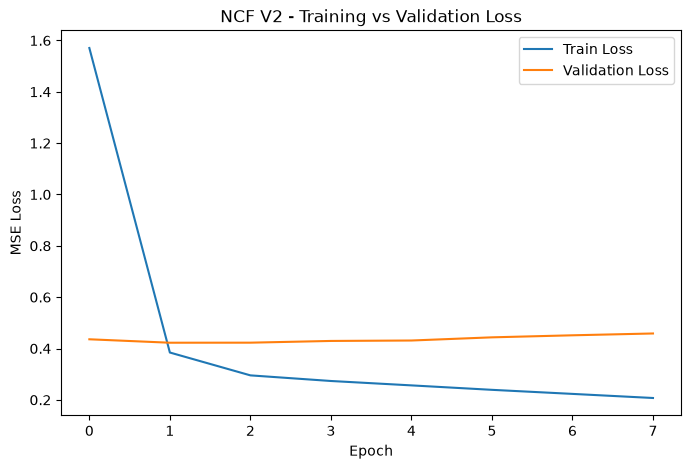

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history_v2.history["loss"], label="Train Loss")
plt.plot(history_v2.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("NCF V2 - Training vs Validation Loss")
plt.legend()
plt.show()

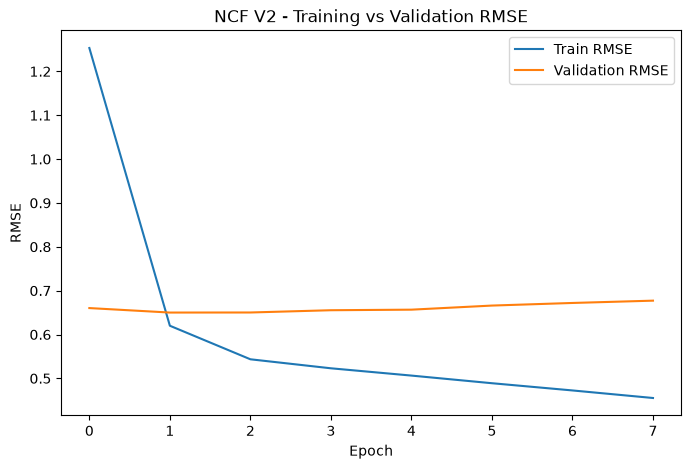

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(history_v2.history["rmse"], label="Train RMSE")
plt.plot(history_v2.history["val_rmse"], label="Validation RMSE")

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("NCF V2 - Training vs Validation RMSE")
plt.legend()
plt.show()

In [83]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

In [84]:
EMBEDDING_DIM = 32
L2_REG = 1e-6

user_input = keras.Input(shape=(1,), name="user")
recipe_input = keras.Input(shape=(1,), name="recipe")

user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=EMBEDDING_DIM,
    embeddings_regularizer=regularizers.l2(L2_REG),
    name="user_embedding"
)(user_input)

recipe_embedding = layers.Embedding(
    input_dim=num_recipes,
    output_dim=EMBEDDING_DIM,
    embeddings_regularizer=regularizers.l2(L2_REG),
    name="recipe_embedding"
)(recipe_input)

user_vector = layers.Flatten()(user_embedding)
recipe_vector = layers.Flatten()(recipe_embedding)

x = layers.Concatenate()([user_vector, recipe_vector])

x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_REG)
)(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_REG)
)(x)

x = layers.Dropout(0.20)(x)

output = layers.Dense(1, activation="linear", name="rating")(x)

model_v3 = keras.Model(
    inputs=[user_input, recipe_input],
    outputs=output
)

model_v3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    545,088 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding    │ (None, 1, 32)     │  1,280,832 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ recipe_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Dense)      │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,832,193 (6.99 MB)

 Trainable params: 1,832,193 (6.99 MB)

 Non-trainable params: 0 (0.00 B)

In [85]:
optimizer_v3 = keras.optimizers.Adam(
    learning_rate=0.001
)

model_v3.compile(
    optimizer=optimizer_v3,
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

In [87]:
early_stopping_v3 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [89]:
history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stopping_v3]
)

Epoch 1/35


C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.4929 - mae: 0.5260 - rmse: 0.6995 - val_loss: 0.4323 - val_mae: 0.4247 - val_rmse: 0.6542
Epoch 2/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.3989 - mae: 0.4631 - rmse: 0.6279 - val_loss: 0.4415 - val_mae: 0.4143 - val_rmse: 0.6606
Epoch 3/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.3329 - mae: 0.4122 - rmse: 0.5723 - val_loss: 0.4587 - val_mae: 0.4318 - val_rmse: 0.6729
Epoch 4/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.2857 - mae: 0.3697 - rmse: 0.5288 - val_loss: 0.4629 - val_mae: 0.4021 - val_rmse: 0.6756
Epoch 5/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.2515 - mae: 0.3330 - rmse: 0.4948 - val_loss: 0.4729 - val_mae: 0.4008 - val_rmse: 0.6825
Epoch 6/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.2259 - mae: 0.3021 - rmse: 0.4675 - val_loss: 0.4920 - val_mae: 0.3886 - val_rmse: 0.6960


In [90]:
test_results_v3 = model_v3.evaluate(
    test_ds,
    return_dict=True
)

print(test_results_v3)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4341 - mae: 0.4240 - rmse: 0.6556
{'loss': 0.434062659740448, 'mae': 0.42395368218421936, 'rmse': 0.6555635929107666}


In [91]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

In [92]:
EMBEDDING_DIM = 32
L2_REG = 1e-6

# Inputs
user_input = keras.Input(shape=(1,), name="user")
recipe_input = keras.Input(shape=(1,), name="recipe")


# =========================
# User representation
# =========================

user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=EMBEDDING_DIM,
    embeddings_regularizer=regularizers.l2(L2_REG),
    name="user_embedding"
)(user_input)

user_vector = layers.Flatten()(user_embedding)


# User bias
user_bias = layers.Embedding(
    input_dim=num_users,
    output_dim=1,
    embeddings_regularizer=regularizers.l2(L2_REG),
    name="user_bias"
)(user_input)

user_bias = layers.Flatten()(user_bias)


# =========================
# Recipe representation
# =========================

recipe_embedding = layers.Embedding(
    input_dim=num_recipes,
    output_dim=EMBEDDING_DIM,
    embeddings_regularizer=regularizers.l2(L2_REG),
    name="recipe_embedding"
)(recipe_input)

recipe_vector = layers.Flatten()(recipe_embedding)


# Recipe bias
recipe_bias = layers.Embedding(
    input_dim=num_recipes,
    output_dim=1,
    embeddings_regularizer=regularizers.l2(L2_REG),
    name="recipe_bias"
)(recipe_input)

recipe_bias = layers.Flatten()(recipe_bias)


# =========================
# NCF interaction
# =========================

interaction = layers.Concatenate()([
    user_vector,
    recipe_vector
])

x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_REG)
)(interaction)

x = layers.Dropout(0.20)(x)

x = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(L2_REG)
)(x)

x = layers.Dropout(0.10)(x)


# =========================
# Combine NCF + biases
# =========================

x = layers.Concatenate()([
    x,
    user_bias,
    recipe_bias
])

output = layers.Dense(
    1,
    activation="linear",
    name="rating"
)(x)


# =========================
# Model
# =========================

model_v4 = keras.Model(
    inputs=[user_input, recipe_input],
    outputs=output
)

model_v4.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    545,088 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding    │ (None, 1, 32)     │  1,280,832 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32)        │          0 │ recipe_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      4,160 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │     17,034 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_bias         │ (None, 1, 1)      │     40,026 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ user_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 1)         │          0 │ recipe_bias[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 34)        │          0 │ dropout_5[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Dense)      │ (None, 1)         │         35 │ concatenate_4[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,889,255 (7.21 MB)

 Trainable params: 1,889,255 (7.21 MB)

 Non-trainable params: 0 (0.00 B)

In [93]:
model_v4.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    545,088 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding    │ (None, 1, 32)     │  1,280,832 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32)        │          0 │ recipe_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 64)        │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      4,160 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias           │ (None, 1, 1)      │     17,034 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_bias         │ (None, 1, 1)      │     40,026 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 1)         │          0 │ user_bias[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 1)         │          0 │ recipe_bias[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 34)        │          0 │ dropout_5[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Dense)      │ (None, 1)         │         35 │ concatenate_4[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,889,255 (7.21 MB)

 Trainable params: 1,889,255 (7.21 MB)

 Non-trainable params: 0 (0.00 B)

In [94]:
optimizer_v4 = keras.optimizers.Adam(
    learning_rate=0.001
)

model_v4.compile(
    optimizer=optimizer_v4,
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

print("V4 model compiled successfully.")

V4 model compiled successfully.


In [95]:
early_stopping_v4 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [96]:
history_v4 = model_v4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stopping_v4]
)

Epoch 1/35


C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


979/979 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 1.6481 - mae: 0.8276 - rmse: 1.2832 - val_loss: 0.4400 - val_mae: 0.4699 - val_rmse: 0.6619
Epoch 2/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.5115 - mae: 0.5363 - rmse: 0.7136 - val_loss: 0.4374 - val_mae: 0.4677 - val_rmse: 0.6594
Epoch 3/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.4560 - mae: 0.5015 - rmse: 0.6730 - val_loss: 0.4439 - val_mae: 0.4565 - val_rmse: 0.6637
Epoch 4/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.4013 - mae: 0.4639 - rmse: 0.6305 - val_loss: 0.4434 - val_mae: 0.4461 - val_rmse: 0.6628
Epoch 5/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - loss: 0.3537 - mae: 0.4284 - rmse: 0.5909 - val_loss: 0.4542 - val_mae: 0.4316 - val_rmse: 0.6703
Epoch 6/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - loss: 0.3218 - mae: 0.4029 - rmse: 0.5627 - val_loss: 0.4674 - val_mae: 0.4456 - val_rmse: 0.6797
Epoch 7/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - loss: 0.2959 - mae: 0.3822 - rm

In [97]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

# =========================
# NCF V5
# =========================

embedding_dim = 16

user_input = keras.Input(shape=(1,), name="user")
recipe_input = keras.Input(shape=(1,), name="recipe")

# User embedding
user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=embedding_dim,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="user_embedding"
)(user_input)

# Recipe embedding
recipe_embedding = layers.Embedding(
    input_dim=num_recipes,
    output_dim=embedding_dim,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="recipe_embedding"
)(recipe_input)

user_vec = layers.Flatten()(user_embedding)
recipe_vec = layers.Flatten()(recipe_embedding)

# Combine user + recipe
x = layers.Concatenate()([user_vec, recipe_vec])

# Shallow MLP
x = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = layers.Dropout(0.30)(x)

x = layers.Dense(
    16,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = layers.Dropout(0.20)(x)

# Rating prediction
rating_output = layers.Dense(
    1,
    activation="linear",
    name="rating"
)(x)

model_v5 = keras.Model(
    inputs=[user_input, recipe_input],
    outputs=rating_output
)

model_v5.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model_v5.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 16)     │    272,544 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding    │ (None, 1, 16)     │    640,416 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 16)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 16)        │          0 │ recipe_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 32)        │          0 │ flatten_6[0][0],  │
│ (Concatenate)       │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      1,056 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 32)        │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │        528 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 16)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Dense)      │ (None, 1)         │         17 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 914,561 (3.49 MB)

 Trainable params: 914,561 (3.49 MB)

 Non-trainable params: 0 (0.00 B)

In [98]:
early_stopping_v5 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    min_delta=0.001,
    restore_best_weights=True
)

In [99]:
history_v5 = model_v5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stopping_v5]
)

Epoch 1/35


C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


979/979 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 2.4042 - mae: 1.1034 - rmse: 1.5483 - val_loss: 0.4720 - val_mae: 0.5250 - val_rmse: 0.6823
Epoch 2/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.8275 - mae: 0.7088 - rmse: 0.9066 - val_loss: 0.4461 - val_mae: 0.4882 - val_rmse: 0.6642
Epoch 3/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.6696 - mae: 0.6275 - rmse: 0.8154 - val_loss: 0.4316 - val_mae: 0.4536 - val_rmse: 0.6534
Epoch 4/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.5894 - mae: 0.5828 - rmse: 0.7648 - val_loss: 0.4375 - val_mae: 0.4466 - val_rmse: 0.6580
Epoch 5/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.5277 - mae: 0.5473 - rmse: 0.7233 - val_loss: 0.4371 - val_mae: 0.4391 - val_rmse: 0.6576
Epoch 6/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 0.4553 - mae: 0.5031 - rmse: 0.6713 - val_loss: 0.4403 - val_mae: 0.4345 - val_rmse: 0.6599


In [100]:
v5_results = model_v5.evaluate(
    test_ds,
    return_dict=True
)

print(v5_results)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4392 - mae: 0.4563 - rmse: 0.6592
{'loss': 0.4391551613807678, 'mae': 0.4563298523426056, 'rmse': 0.6592199802398682}


In [102]:
# ==========================================
# NCF V6 - NeuMF
# ==========================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

embedding_dim = 16

# Inputs
user_input = keras.Input(shape=(1,), name="user")
recipe_input = keras.Input(shape=(1,), name="recipe")


# ------------------------------------------
# GMF branch
# ------------------------------------------

gmf_user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=embedding_dim,
    name="gmf_user_embedding"
)(user_input)

gmf_recipe_embedding = layers.Embedding(
    input_dim=num_recipes,
    output_dim=embedding_dim,
    name="gmf_recipe_embedding"
)(recipe_input)

gmf_user = layers.Flatten()(gmf_user_embedding)
gmf_recipe = layers.Flatten()(gmf_recipe_embedding)

# Element-wise multiplication
gmf = layers.Multiply()([gmf_user, gmf_recipe])


# ------------------------------------------
# MLP branch
# ------------------------------------------

mlp_user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=embedding_dim,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="mlp_user_embedding"
)(user_input)

mlp_recipe_embedding = layers.Embedding(
    input_dim=num_recipes,
    output_dim=embedding_dim,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="mlp_recipe_embedding"
)(recipe_input)

mlp_user = layers.Flatten()(mlp_user_embedding)
mlp_recipe = layers.Flatten()(mlp_recipe_embedding)

mlp = layers.Concatenate()([mlp_user, mlp_recipe])

mlp = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(mlp)

mlp = layers.Dropout(0.3)(mlp)

mlp = layers.Dense(
    16,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(mlp)

mlp = layers.Dropout(0.2)(mlp)


# ------------------------------------------
# Combine GMF + MLP
# ------------------------------------------

combined = layers.Concatenate()([gmf, mlp])

rating_output = layers.Dense(
    1,
    activation="linear",
    name="rating"
)(combined)


# ------------------------------------------
# Build model
# ------------------------------------------

model_v6 = keras.Model(
    inputs=[user_input, recipe_input],
    outputs=rating_output
)


# ------------------------------------------
# Compile
# ------------------------------------------

model_v6.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model_v6.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_user_embedding  │ (None, 1, 16)     │    272,544 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_recipe_embeddi… │ (None, 1, 16)     │    640,416 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 16)        │          0 │ mlp_user_embeddi… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 16)        │          0 │ mlp_recipe_embed… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 32)        │          0 │ flatten_12[0][0], │
│ (Concatenate)       │                   │            │ flatten_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 32)        │      1,056 │ concatenate_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_user_embedding  │ (None, 1, 16)     │    272,544 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmf_recipe_embeddi… │ (None, 1, 16)     │    640,416 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 32)        │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 16)        │          0 │ gmf_user_embeddi… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 16)        │          0 │ gmf_recipe_embed… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 16)        │        528 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16)        │          0 │ flatten_10[0][0], │
│                     │                   │            │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 16)        │          0 │ dense_14[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 32)        │          0 │ multiply[0][0],   │
│ (Concatenate)       │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Dense)      │ (None, 1)         │         33 │ concatenate_8[0]… │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 1,827,537 (6.97 MB)

 Trainable params: 1,827,537 (6.97 MB)

 Non-trainable params: 0 (0.00 B)

In [106]:
early_stopping_v6 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=0.001,
    restore_best_weights=True
)

In [107]:
history_v6 = model_v6.fit(
    train_ds,
    validation_data=val_ds,
    epochs=55,
    callbacks=[early_stopping_v6]
)

Epoch 1/55


C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.5118 - mae: 0.5390 - rmse: 0.7123 - val_loss: 0.4357 - val_mae: 0.4591 - val_rmse: 0.6568
Epoch 2/55
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.3763 - mae: 0.4578 - rmse: 0.6100 - val_loss: 0.4486 - val_mae: 0.4649 - val_rmse: 0.6666
Epoch 3/55
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.2638 - mae: 0.3798 - rmse: 0.5096 - val_loss: 0.4663 - val_mae: 0.4643 - val_rmse: 0.6798
Epoch 4/55
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.1816 - mae: 0.3106 - rmse: 0.4213 - val_loss: 0.4868 - val_mae: 0.4791 - val_rmse: 0.6947
Epoch 5/55
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.1287 - mae: 0.2556 - rmse: 0.3529 - val_loss: 0.4957 - val_mae: 0.4689 - val_rmse: 0.7011
Epoch 6/55
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.0981 - mae: 0.2169 - rmse: 0.3066 - val_loss: 0.5123 - val_mae: 0.4863 - val_rmse: 0.7129
Epoch 7/55
979/979 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.0808 - mae: 0.1936 - rm

In [108]:
global_mean = train["rating"].mean()

pred_global = np.full(
    len(test),
    global_mean
)

global_rmse = np.sqrt(
    np.mean(
        (test["rating"].values - pred_global) ** 2
    )
)

global_mae = np.mean(
    np.abs(
        test["rating"].values - pred_global
    )
)

print("Global mean:", global_mean)
print("Global RMSE:", global_rmse)
print("Global MAE:", global_mae)

Global mean: 4.729515608438677
Global RMSE: 0.6722252876963897
Global MAE: 0.437515088982283


In [109]:
user_means = (
    train.groupby("user_id")["rating"]
    .mean()
)

test_user_mean = test["user_id"].map(user_means)

# Ako se nekim slučajem pojavi user koji nema train rating,
# koristimo globalni prosek
test_user_mean = test_user_mean.fillna(global_mean)

user_rmse = np.sqrt(
    np.mean(
        (test["rating"].values - test_user_mean.values) ** 2
    )
)

user_mae = np.mean(
    np.abs(
        test["rating"].values - test_user_mean.values
    )
)

print("User mean RMSE:", user_rmse)
print("User mean MAE:", user_mae)

User mean RMSE: 0.6823998541997913
User mean MAE: 0.397641025832248


In [110]:
recipe_means = (
    train.groupby("recipe_id")["rating"]
    .mean()
)

test_recipe_mean = test["recipe_id"].map(recipe_means)

test_recipe_mean = test_recipe_mean.fillna(global_mean)

user_means_test = (
    test["user_id"]
    .map(user_means)
    .fillna(global_mean)
)

# Kombinujemo user i recipe preference
pred_bias = (
        user_means_test
        + test_recipe_mean
        - global_mean
)

# Ograničimo predikciju na validan rating range
pred_bias = pred_bias.clip(0, 5)

bias_rmse = np.sqrt(
    np.mean(
        (test["rating"].values - pred_bias.values) ** 2
    )
)

bias_mae = np.mean(
    np.abs(
        test["rating"].values - pred_bias.values
    )
)

print("User + Recipe bias RMSE:", bias_rmse)
print("User + Recipe bias MAE:", bias_mae)

User + Recipe bias RMSE: 0.6800554785719135
User + Recipe bias MAE: 0.4027288552403825


In [111]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

tf.random.set_seed(42)
np.random.seed(42)

embedding_dim = 32

user_input = keras.Input(shape=(1,), name="user")
recipe_input = keras.Input(shape=(1,), name="recipe")

user_embedding = layers.Embedding(
    input_dim=num_users,
    output_dim=embedding_dim,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="user_embedding"
)(user_input)

recipe_embedding = layers.Embedding(
    input_dim=num_recipes,
    output_dim=embedding_dim,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="recipe_embedding"
)(recipe_input)

user_vector = layers.Flatten()(user_embedding)
recipe_vector = layers.Flatten()(recipe_embedding)

x = layers.Concatenate()([user_vector, recipe_vector])

x = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(x)

x = layers.Dropout(0.30)(x)

output = layers.Dense(1, name="rating")(x)

model_v6 = keras.Model(
    inputs=[user_input, recipe_input],
    outputs=output,
    name="NCF_V6"
)

model_v6.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        "mae",
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model_v6.summary()

Model: "NCF_V6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    545,088 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding    │ (None, 1, 32)     │  1,280,832 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_15          │ (None, 32)        │          0 │ recipe_embedding… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 64)        │          0 │ flatten_14[0][0], │
│ (Concatenate)       │                   │            │ flatten_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 32)        │      2,080 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 32)        │          0 │ dense_15[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Dense)      │ (None, 1)         │         33 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,828,033 (6.97 MB)

 Trainable params: 1,828,033 (6.97 MB)

 Non-trainable params: 0 (0.00 B)

In [112]:
early_stopping_v6 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    min_delta=0.001,
    restore_best_weights=True
)

In [113]:
history_v6 = model_v6.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stopping_v6]
)

Epoch 1/35


C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


979/979 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - loss: 2.9328 - mae: 1.2288 - rmse: 1.7102 - val_loss: 0.5250 - val_mae: 0.5284 - val_rmse: 0.7194
Epoch 2/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 0.7634 - mae: 0.6772 - rmse: 0.8699 - val_loss: 0.4687 - val_mae: 0.4834 - val_rmse: 0.6801
Epoch 3/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 0.7097 - mae: 0.6516 - rmse: 0.8390 - val_loss: 0.4580 - val_mae: 0.4742 - val_rmse: 0.6726
Epoch 4/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.6477 - mae: 0.6213 - rmse: 0.8014 - val_loss: 0.4475 - val_mae: 0.4565 - val_rmse: 0.6649
Epoch 5/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - loss: 0.5755 - mae: 0.5824 - rmse: 0.7550 - val_loss: 0.4497 - val_mae: 0.4632 - val_rmse: 0.6664
Epoch 6/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - loss: 0.4984 - mae: 0.5370 - rmse: 0.7019 - val_loss: 0.4497 - val_mae: 0.4615 - val_rmse: 0.6662
Epoch 7/35
979/979 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - loss: 0.4254 - mae: 0.4890 - rm

In [114]:
v6_results = model_v6.evaluate(
    test_ds,
    return_dict=True
)

print(v6_results)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4391 - mae: 0.4091 - rmse: 0.6569
{'loss': 0.43914616107940674, 'mae': 0.4090937674045563, 'rmse': 0.6568784713745117}


In [115]:
MIN_USER_RATINGS = 10
MIN_RECIPE_RATINGS = 10

filtered_ratings_v7 = explicit_ratings.copy()

while True:
    user_counts = filtered_ratings_v7.groupby("user_id").size()
    recipe_counts = filtered_ratings_v7.groupby("recipe_id").size()

    valid_users = user_counts[user_counts >= MIN_USER_RATINGS].index
    valid_recipes = recipe_counts[recipe_counts >= MIN_RECIPE_RATINGS].index

    new_filtered = filtered_ratings_v7[
        filtered_ratings_v7["user_id"].isin(valid_users)
        & filtered_ratings_v7["recipe_id"].isin(valid_recipes)
        ].copy()

    if len(new_filtered) == len(filtered_ratings_v7):
        break

    filtered_ratings_v7 = new_filtered

print("Interactions:", len(filtered_ratings_v7))
print("Users:", filtered_ratings_v7["user_id"].nunique())
print("Recipes:", filtered_ratings_v7["recipe_id"].nunique())

NameError: name 'explicit_ratings' is not defined

In [116]:
MIN_USER_RATINGS = 10
MIN_RECIPE_RATINGS = 10

filtered_ratings_v7 = interactions[
    interactions["rating"] > 0
    ].copy()

while True:
    user_counts = filtered_ratings_v7.groupby("user_id").size()
    recipe_counts = filtered_ratings_v7.groupby("recipe_id").size()

    valid_users = user_counts[
        user_counts >= MIN_USER_RATINGS
        ].index

    valid_recipes = recipe_counts[
        recipe_counts >= MIN_RECIPE_RATINGS
        ].index

    new_filtered = filtered_ratings_v7[
        filtered_ratings_v7["user_id"].isin(valid_users)
        & filtered_ratings_v7["recipe_id"].isin(valid_recipes)
        ].copy()

    if len(new_filtered) == len(filtered_ratings_v7):
        break

    filtered_ratings_v7 = new_filtered

print("V7 interactions:", len(filtered_ratings_v7))
print("V7 users:", filtered_ratings_v7["user_id"].nunique())
print("V7 recipes:", filtered_ratings_v7["recipe_id"].nunique())

V7 interactions: 298969
V7 users: 7196
V7 recipes: 12474


In [117]:
explicit_ratings = interactions[interactions["rating"] > 0].copy()

In [118]:
from sklearn.model_selection import train_test_split

train_ratings_v7, test_ratings_v7 = train_test_split(
    filtered_ratings_v7,
    test_size=0.20,
    random_state=42
)

print("Train interactions:", len(train_ratings_v7))
print("Test interactions:", len(test_ratings_v7))
print("Total:", len(train_ratings_v7) + len(test_ratings_v7))

Train interactions: 239175
Test interactions: 59794
Total: 298969


In [119]:
train_users_v7 = set(train_ratings_v7["user_id"])
test_users_v7 = set(test_ratings_v7["user_id"])

train_recipes_v7 = set(train_ratings_v7["recipe_id"])
test_recipes_v7 = set(test_ratings_v7["recipe_id"])

cold_start_users_v7 = test_users_v7 - train_users_v7
cold_start_recipes_v7 = test_recipes_v7 - train_recipes_v7

print("Cold-start users:", len(cold_start_users_v7))
print("Cold-start recipes:", len(cold_start_recipes_v7))

Cold-start users: 0
Cold-start recipes: 0


In [120]:
# V7 - Encode users and recipes

user_ids_v7 = train_ratings_v7["user_id"].unique()
recipe_ids_v7 = train_ratings_v7["recipe_id"].unique()

user_to_index_v7 = {
    user_id: idx
    for idx, user_id in enumerate(user_ids_v7)
}

recipe_to_index_v7 = {
    recipe_id: idx
    for idx, recipe_id in enumerate(recipe_ids_v7)
}

train_ratings_v7 = train_ratings_v7.copy()
test_ratings_v7 = test_ratings_v7.copy()

train_ratings_v7["user_idx"] = train_ratings_v7["user_id"].map(user_to_index_v7)
train_ratings_v7["recipe_idx"] = train_ratings_v7["recipe_id"].map(recipe_to_index_v7)

test_ratings_v7["user_idx"] = test_ratings_v7["user_id"].map(user_to_index_v7)
test_ratings_v7["recipe_idx"] = test_ratings_v7["recipe_id"].map(recipe_to_index_v7)

print("V7 users:", len(user_to_index_v7))
print("V7 recipes:", len(recipe_to_index_v7))

V7 users: 7196
V7 recipes: 12474


In [121]:
# ============================================
# V7 - Mapiranje user/recipe ID-eva
# ============================================

user_ids = train_ratings_v7["user_id"].unique()
recipe_ids = train_ratings_v7["recipe_id"].unique()

user2idx_v7 = {user_id: idx for idx, user_id in enumerate(user_ids)}
recipe2idx_v7 = {recipe_id: idx for idx, recipe_id in enumerate(recipe_ids)}

train_v7 = train_ratings_v7.copy()
test_v7 = test_ratings_v7.copy()

train_v7["user_idx"] = train_v7["user_id"].map(user2idx_v7)
train_v7["recipe_idx"] = train_v7["recipe_id"].map(recipe2idx_v7)

test_v7["user_idx"] = test_v7["user_id"].map(user2idx_v7)
test_v7["recipe_idx"] = test_v7["recipe_id"].map(recipe2idx_v7)

print("Users:", len(user2idx_v7))
print("Recipes:", len(recipe2idx_v7))

print("Missing user mappings:", train_v7["user_idx"].isna().sum())
print("Missing recipe mappings:", train_v7["recipe_idx"].isna().sum())

print("Test missing user mappings:", test_v7["user_idx"].isna().sum())
print("Test missing recipe mappings:", test_v7["recipe_idx"].isna().sum())

Users: 7196
Recipes: 12474
Missing user mappings: 0
Missing recipe mappings: 0
Test missing user mappings: 0
Test missing recipe mappings: 0


In [122]:
import tensorflow as tf

BATCH_SIZE = 256

X_train_v7 = {
    "user": train_v7["user_idx"].astype("int32").values,
    "recipe": train_v7["recipe_idx"].astype("int32").values
}

y_train_v7 = train_v7["rating"].astype("float32").values

X_test_v7 = {
    "user": test_v7["user_idx"].astype("int32").values,
    "recipe": test_v7["recipe_idx"].astype("int32").values
}

y_test_v7 = test_v7["rating"].astype("float32").values

train_ds_v7 = tf.data.Dataset.from_tensor_slices(
    (X_train_v7, y_train_v7)
).shuffle(
    10000,
    seed=42
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

test_ds_v7 = tf.data.Dataset.from_tensor_slices(
    (X_test_v7, y_test_v7)
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)

print("Train:", len(train_v7))
print("Test:", len(test_v7))

Train: 239175
Test: 59794


In [123]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

NUM_USERS_V7 = len(user2idx_v7)
NUM_RECIPES_V7 = len(recipe2idx_v7)

EMBEDDING_DIM_V7 = 16

user_input_v7 = keras.Input(
    shape=(1,),
    name="user"
)

recipe_input_v7 = keras.Input(
    shape=(1,),
    name="recipe"
)

user_embedding_v7 = layers.Embedding(
    input_dim=NUM_USERS_V7,
    output_dim=EMBEDDING_DIM_V7,
    embeddings_regularizer=regularizers.l2(1e-5),
    name="user_embedding"
)(user_input_v7)

recipe_embedding_v7 = layers.Embedding(
    input_dim=NUM_RECIPES_V7,
    output_dim=EMBEDDING_DIM_V7,
    embeddings_regularizer=regularizers.l2(1e-5),
    name="recipe_embedding"
)(recipe_input_v7)

user_vector_v7 = layers.Flatten()(user_embedding_v7)
recipe_vector_v7 = layers.Flatten()(recipe_embedding_v7)

concat_v7 = layers.Concatenate()([
    user_vector_v7,
    recipe_vector_v7
])

dense_v7 = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(concat_v7)

dropout_v7 = layers.Dropout(0.30)(dense_v7)

dense2_v7 = layers.Dense(
    16,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-4)
)(dropout_v7)

dropout2_v7 = layers.Dropout(0.20)(dense2_v7)

rating_output_v7 = layers.Dense(
    1,
    activation="linear",
    name="rating"
)(dropout2_v7)

model_v7 = keras.Model(
    inputs=[user_input_v7, recipe_input_v7],
    outputs=rating_output_v7
)

model_v7.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model_v7.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 16)     │    115,136 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding    │ (None, 1, 16)     │    199,584 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_16          │ (None, 16)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_17          │ (None, 16)        │          0 │ recipe_embedding… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 32)        │          0 │ flatten_16[0][0], │
│ (Concatenate)       │                   │            │ flatten_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 32)        │      1,056 │ concatenate_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 32)        │          0 │ dense_16[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 16)        │        528 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 16)        │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Dense)      │ (None, 1)         │         17 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 316,321 (1.21 MB)

 Trainable params: 316,321 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [124]:
early_stopping_v7 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=0.001,
    restore_best_weights=True
)

In [125]:
history_v7 = model_v7.fit(
    train_ds_v7,
    validation_data=test_ds_v7,
    epochs=55,
    callbacks=[early_stopping_v7]
)

Epoch 1/55


C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


935/935 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 3.5805 - mae: 1.4022 - rmse: 1.8899 - val_loss: 0.3983 - val_mae: 0.5225 - val_rmse: 0.6242
Epoch 2/55
935/935 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.2943 - mae: 0.8974 - rmse: 1.1340 - val_loss: 0.3488 - val_mae: 0.4597 - val_rmse: 0.5837
Epoch 3/55
935/935 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.0857 - mae: 0.8142 - rmse: 1.0381 - val_loss: 0.3477 - val_mae: 0.4581 - val_rmse: 0.5828
Epoch 4/55
935/935 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.8806 - mae: 0.7255 - rmse: 0.9340 - val_loss: 0.3492 - val_mae: 0.4621 - val_rmse: 0.5838
Epoch 5/55
935/935 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.7140 - mae: 0.6455 - rmse: 0.8399 - val_loss: 0.3373 - val_mae: 0.4396 - val_rmse: 0.5732
Epoch 6/55
935/935 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.5864 - mae: 0.5791 - rmse: 0.7598 - val_loss: 0.3284 - val_mae: 0.4067 - val_rmse: 0.5648
Epoch 7/55
935/935 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.4732 - mae: 0.5100 - rmse: 0.6807 - 

In [126]:
from sklearn.model_selection import train_test_split

train_mf, val_mf = train_test_split(
    train_ratings_v7,
    test_size=0.10,
    random_state=42
)

print("MF train:", len(train_mf))
print("MF validation:", len(val_mf))
print("Final test:", len(test_ratings_v7))

MF train: 215257
MF validation: 23918
Final test: 59794


In [127]:
BATCH_SIZE_MF = 256

X_train_mf = {
    "user": train_mf["user_id"].map(user2idx_v7).astype("int32").values,
    "recipe": train_mf["recipe_id"].map(recipe2idx_v7).astype("int32").values
}

y_train_mf = train_mf["rating"].astype("float32").values


X_val_mf = {
    "user": val_mf["user_id"].map(user2idx_v7).astype("int32").values,
    "recipe": val_mf["recipe_id"].map(recipe2idx_v7).astype("int32").values
}

y_val_mf = val_mf["rating"].astype("float32").values


X_test_mf = {
    "user": test_ratings_v7["user_id"].map(user2idx_v7).astype("int32").values,
    "recipe": test_ratings_v7["recipe_id"].map(recipe2idx_v7).astype("int32").values
}

y_test_mf = test_ratings_v7["rating"].astype("float32").values


train_ds_mf = tf.data.Dataset.from_tensor_slices(
    (X_train_mf, y_train_mf)
).shuffle(
    10000,
    seed=42
).batch(
    BATCH_SIZE_MF
).prefetch(
    tf.data.AUTOTUNE
)


val_ds_mf = tf.data.Dataset.from_tensor_slices(
    (X_val_mf, y_val_mf)
).batch(
    BATCH_SIZE_MF
).prefetch(
    tf.data.AUTOTUNE
)


test_ds_mf = tf.data.Dataset.from_tensor_slices(
    (X_test_mf, y_test_mf)
).batch(
    BATCH_SIZE_MF
).prefetch(
    tf.data.AUTOTUNE
)

print("Datasets ready.")

Datasets ready.


In [128]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers

EMBEDDING_DIM_MF = 32

user_input_mf = keras.Input(
    shape=(1,),
    dtype="int32",
    name="user"
)

recipe_input_mf = keras.Input(
    shape=(1,),
    dtype="int32",
    name="recipe"
)


user_embedding_mf = layers.Embedding(
    input_dim=NUM_USERS_V7,
    output_dim=EMBEDDING_DIM_MF,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="user_embedding_mf"
)(user_input_mf)

recipe_embedding_mf = layers.Embedding(
    input_dim=NUM_RECIPES_V7,
    output_dim=EMBEDDING_DIM_MF,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="recipe_embedding_mf"
)(recipe_input_mf)


user_bias_mf = layers.Embedding(
    input_dim=NUM_USERS_V7,
    output_dim=1,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="user_bias_mf"
)(user_input_mf)

recipe_bias_mf = layers.Embedding(
    input_dim=NUM_RECIPES_V7,
    output_dim=1,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="recipe_bias_mf"
)(recipe_input_mf)


user_vector_mf = layers.Flatten()(user_embedding_mf)
recipe_vector_mf = layers.Flatten()(recipe_embedding_mf)

user_bias_mf = layers.Flatten()(user_bias_mf)
recipe_bias_mf = layers.Flatten()(recipe_bias_mf)


dot_product_mf = layers.Dot(
    axes=1
)([
    user_vector_mf,
    recipe_vector_mf
])


global_mean_mf = float(train_mf["rating"].mean())

global_mean_layer = layers.Lambda(
    lambda x: x * 0.0 + global_mean_mf,
    name="global_mean"
)(dot_product_mf)


rating_output_mf = layers.Add(name="rating")([
    dot_product_mf,
    user_bias_mf,
    recipe_bias_mf,
    global_mean_layer
])


model_v8 = keras.Model(
    inputs=[user_input_mf, recipe_input_mf],
    outputs=rating_output_mf
)


model_v8.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model_v8.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding_mf   │ (None, 1, 32)     │    230,272 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding_mf │ (None, 1, 32)     │    399,168 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_18          │ (None, 32)        │          0 │ user_embedding_m… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_19          │ (None, 32)        │          0 │ recipe_embedding… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten_18[0][0], │
│                     │                   │            │ flatten_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_bias_mf        │ (None, 1, 1)      │      7,196 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_bias_mf      │ (None, 1, 1)      │     12,474 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_20          │ (None, 1)         │          0 │ user_bias_mf[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_21          │ (None, 1)         │          0 │ recipe_bias_mf[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_mean         │ (None, 1)         │          0 │ dot[0][0]         │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating (Add)        │ (None, 1)         │          0 │ dot[0][0],        │
│                     │                   │            │ flatten_20[0][0], │
│                     │                   │            │ flatten_21[0][0], │
│                     │                   │            │ global_mean[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 649,110 (2.48 MB)

 Trainable params: 649,110 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [129]:
early_stopping_v8 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    min_delta=0.001,
    restore_best_weights=True
)

In [130]:
history_v8 = model_v8.fit(
    train_ds_mf,
    validation_data=val_ds_mf,
    epochs=40,
    callbacks=[early_stopping_v8]
)

Epoch 1/40


C:\Users\Nikola\Desktop\FoodRecommendationSystem\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


841/841 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.3414 - mae: 0.3820 - rmse: 0.5838 - val_loss: 0.3242 - val_mae: 0.3591 - val_rmse: 0.5688
Epoch 2/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.3035 - mae: 0.3366 - rmse: 0.5497 - val_loss: 0.3149 - val_mae: 0.3475 - val_rmse: 0.5592
Epoch 3/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2555 - mae: 0.2957 - rmse: 0.5021 - val_loss: 0.3166 - val_mae: 0.3495 - val_rmse: 0.5584
Epoch 4/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1980 - mae: 0.2456 - rmse: 0.4378 - val_loss: 0.3271 - val_mae: 0.3580 - val_rmse: 0.5650
Epoch 5/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1504 - mae: 0.2027 - rmse: 0.3756 - val_loss: 0.3412 - val_mae: 0.3680 - val_rmse: 0.5748
Epoch 6/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1162 - mae: 0.1712 - rmse: 0.3227 - val_loss: 0.3555 - val_mae: 0.3773 - val_rmse: 0.5850
Epoch 7/40
841/841 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0921 - mae: 0.1480 - rmse: 0.2790 - v

In [131]:
v8_test_results = model_v8.evaluate(
    test_ds_mf,
    return_dict=True
)

print(v8_test_results)

234/234 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3209 - mae: 0.3504 - rmse: 0.5646
{'loss': 0.3208547532558441, 'mae': 0.3503822982311249, 'rmse': 0.5645677447319031}


In [132]:
print(model_v7)
print(len(user2idx_v7))
print(len(recipe2idx_v7))

<Functional name=functional_7, built=True>
7196
12474


In [133]:
# ============================================
# V7 - Precision@10 and Recall@10
# ============================================

K = 10
RELEVANT_THRESHOLD = 4

# Svi korisnici koji imaju test interakcije
eval_users = test_ratings_v7["user_id"].unique()

# Relevantni recepti u test skupu: rating >= 4
test_relevant = (
    test_ratings_v7[test_ratings_v7["rating"] >= RELEVANT_THRESHOLD]
    .groupby("user_id")["recipe_id"]
    .apply(set)
    .to_dict()
)

# Recepti koje je svaki korisnik već imao u TRAIN skupu
train_seen = (
    train_ratings_v7
    .groupby("user_id")["recipe_id"]
    .apply(set)
    .to_dict()
)

# Samo korisnici koji imaju bar jedan relevantan recept u testu
eval_users = [
    user_id
    for user_id in eval_users
    if user_id in test_relevant and len(test_relevant[user_id]) > 0
]

print("Evaluation users:", len(eval_users))

# Svi recepti koje model poznaje
all_recipe_ids = np.array(list(recipe2idx_v7.keys()))
all_recipe_indices = np.array(
    [recipe2idx_v7[rid] for rid in all_recipe_ids],
    dtype=np.int32
)

user_indices = np.array(
    [user2idx_v7[uid] for uid in eval_users],
    dtype=np.int32
)

precision_scores = []
recall_scores = []

# Radimo više korisnika odjednom da ne trošimo ogromnu memoriju
USER_BATCH_SIZE = 64

for start in range(0, len(eval_users), USER_BATCH_SIZE):

    batch_users = eval_users[start:start + USER_BATCH_SIZE]
    batch_user_indices = user_indices[start:start + USER_BATCH_SIZE]

    n_users = len(batch_users)
    n_recipes = len(all_recipe_indices)

    # Svaki korisnik dobija sve recepte kao kandidate
    user_array = np.repeat(
        batch_user_indices,
        n_recipes
    )

    recipe_array = np.tile(
        all_recipe_indices,
        n_users
    )

    # Predikcije V7 modela
    predictions = model_v7.predict(
        {
            "user": user_array,
            "recipe": recipe_array
        },
        batch_size=4096,
        verbose=0
    ).reshape(n_users, n_recipes)

    # Za svakog korisnika uklanjamo recepte
    # koje je već imao u TRAIN skupu
    for i, user_id in enumerate(batch_users):

        seen_recipes = train_seen.get(user_id, set())

        for recipe_id in seen_recipes:
            if recipe_id in recipe2idx_v7:
                recipe_idx = recipe2idx_v7[recipe_id]
                recipe_position = np.where(
                    all_recipe_indices == recipe_idx
                )[0]

                if len(recipe_position) > 0:
                    predictions[i, recipe_position[0]] = -np.inf

        # Top 10 preporuka
        top10_positions = np.argpartition(
            predictions[i],
            -K
        )[-K:]

        top10_positions = top10_positions[
            np.argsort(predictions[i][top10_positions])[::-1]
        ]

        recommended_recipes = set(
            all_recipe_ids[top10_positions]
        )

        relevant_recipes = test_relevant[user_id]

        hits = len(
            recommended_recipes.intersection(relevant_recipes)
        )

        precision = hits / K
        recall = hits / len(relevant_recipes)

        precision_scores.append(precision)
        recall_scores.append(recall)

    print(
        f"Processed {min(start + USER_BATCH_SIZE, len(eval_users))}"
        f"/{len(eval_users)} users"
    )


precision_at_10 = np.mean(precision_scores)
recall_at_10 = np.mean(recall_scores)

print("\n====================================")
print("V7 Recommendation Evaluation")
print("====================================")
print(f"Precision@10: {precision_at_10:.4f}")
print(f"Recall@10:    {recall_at_10:.4f}")
print(f"Users evaluated: {len(eval_users)}")

Evaluation users: 6929
Processed 64/6929 users
Processed 128/6929 users
Processed 192/6929 users
Processed 256/6929 users
Processed 320/6929 users
Processed 384/6929 users
Processed 448/6929 users
Processed 512/6929 users
Processed 576/6929 users
Processed 640/6929 users
Processed 704/6929 users
Processed 768/6929 users
Processed 832/6929 users
Processed 896/6929 users
Processed 960/6929 users
Processed 1024/6929 users
Processed 1088/6929 users
Processed 1152/6929 users
Processed 1216/6929 users
Processed 1280/6929 users
Processed 1344/6929 users
Processed 1408/6929 users
Processed 1472/6929 users
Processed 1536/6929 users
Processed 1600/6929 users
Processed 1664/6929 users
Processed 1728/6929 users
Processed 1792/6929 users
Processed 1856/6929 users
Processed 1920/6929 users
Processed 1984/6929 users
Processed 2048/6929 users
Processed 2112/6929 users
Processed 2176/6929 users
Processed 2240/6929 users
Processed 2304/6929 users
Processed 2368/6929 users
Processed 2432/6929 users
Proce

In [134]:
# Pozitivne interakcije
positive_train_v9 = train_ratings_v7[
    train_ratings_v7["rating"] >= 4
    ].copy()

positive_test_v9 = test_ratings_v7[
    test_ratings_v7["rating"] >= 4
    ].copy()

print("Positive train interactions:", len(positive_train_v9))
print("Positive test interactions:", len(positive_test_v9))
print("Train users:", positive_train_v9["user_id"].nunique())
print("Test users:", positive_test_v9["user_id"].nunique())

Positive train interactions: 228492
Positive test interactions: 57066
Train users: 7195
Test users: 6929


In [135]:
user_ids_v9 = sorted(train_ratings_v7["user_id"].unique())
recipe_ids_v9 = sorted(train_ratings_v7["recipe_id"].unique())

user_to_idx_v9 = {
    user_id: idx
    for idx, user_id in enumerate(user_ids_v9)
}

recipe_to_idx_v9 = {
    recipe_id: idx
    for idx, recipe_id in enumerate(recipe_ids_v9)
}

num_users_v9 = len(user_to_idx_v9)
num_recipes_v9 = len(recipe_to_idx_v9)

print("Users:", num_users_v9)
print("Recipes:", num_recipes_v9)

Users: 7196
Recipes: 12474


In [136]:
import numpy as np

rng = np.random.default_rng(42)

positive_pairs_v9 = set(
    zip(
        positive_train_v9["user_id"],
        positive_train_v9["recipe_id"]
    )
)

all_recipe_ids_v9 = np.array(recipe_ids_v9)

negative_samples_per_positive = 4

train_users_v9 = []
train_recipes_v9 = []
train_labels_v9 = []

for user_id, recipe_id in positive_pairs_v9:

    # Positive
    train_users_v9.append(user_to_idx_v9[user_id])
    train_recipes_v9.append(recipe_to_idx_v9[recipe_id])
    train_labels_v9.append(1.0)

    # Negative samples
    sampled = 0

    while sampled < negative_samples_per_positive:

        negative_recipe_id = rng.choice(all_recipe_ids_v9)

        if (user_id, negative_recipe_id) not in positive_pairs_v9:
            train_users_v9.append(user_to_idx_v9[user_id])
            train_recipes_v9.append(recipe_to_idx_v9[negative_recipe_id])
            train_labels_v9.append(0.0)

            sampled += 1

In [137]:
train_users_v9 = np.array(train_users_v9)
train_recipes_v9 = np.array(train_recipes_v9)
train_labels_v9 = np.array(train_labels_v9)

print("Training examples:", len(train_labels_v9))
print("Positive:", np.sum(train_labels_v9 == 1))
print("Negative:", np.sum(train_labels_v9 == 0))

Training examples: 1142460
Positive: 228492
Negative: 913968


In [138]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

In [139]:
embedding_dim = 32

user_input = keras.Input(
    shape=(1,),
    name="user"
)

recipe_input = keras.Input(
    shape=(1,),
    name="recipe"
)

user_embedding = layers.Embedding(
    input_dim=num_users_v9,
    output_dim=embedding_dim,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="user_embedding"
)(user_input)

recipe_embedding = layers.Embedding(
    input_dim=num_recipes_v9,
    output_dim=embedding_dim,
    embeddings_regularizer=regularizers.l2(1e-6),
    name="recipe_embedding"
)(recipe_input)

user_vec = layers.Flatten()(user_embedding)
recipe_vec = layers.Flatten()(recipe_embedding)

# GMF branch
gmf = layers.Multiply()([
    user_vec,
    recipe_vec
])

# MLP branch
mlp = layers.Concatenate()([
    user_vec,
    recipe_vec
])

mlp = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-5)
)(mlp)

mlp = layers.Dropout(0.30)(mlp)

mlp = layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-5)
)(mlp)

mlp = layers.Dropout(0.20)(mlp)

combined = layers.Concatenate()([
    gmf,
    mlp
])

output = layers.Dense(
    1,
    activation="sigmoid",
    name="score"
)(combined)

model_v9 = keras.Model(
    inputs=[user_input, recipe_input],
    outputs=output
)

model_v9.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │    230,272 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recipe_embedding    │ (None, 1, 32)     │    399,168 │ recipe[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_22          │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_23          │ (None, 32)        │          0 │ recipe_embedding… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 64)        │          0 │ flatten_22[0][0], │
│ (Concatenate)       │                   │            │ flatten_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 64)        │      4,160 │ concatenate_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 64)        │          0 │ dense_18[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 32)        │      2,080 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 32)        │          0 │ flatten_22[0][0], │
│ (Multiply)          │                   │            │ flatten_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 32)        │          0 │ dense_19[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_12      │ (None, 64)        │          0 │ multiply_1[0][0], │
│ (Concatenate)       │                   │            │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ score (Dense)       │ (None, 1)         │         65 │ concatenate_12[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 635,745 (2.43 MB)

 Trainable params: 635,745 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

In [140]:
model_v9.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(name="auc")
    ]
)

In [142]:
early_stopping_v9 = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=6,
    restore_best_weights=True
)

In [143]:
history_v9 = model_v9.fit(
    [train_users_v9, train_recipes_v9],
    train_labels_v9,
    validation_split=0.10,
    epochs=40,
    batch_size=1024,
    callbacks=[early_stopping_v9],
    verbose=1
)

Epoch 1/40
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - auc: 0.6546 - loss: 0.4734 - val_auc: 0.7067 - val_loss: 0.4493
Epoch 2/40
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - auc: 0.7271 - loss: 0.4415 - val_auc: 0.7329 - val_loss: 0.4396
Epoch 3/40
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - auc: 0.7688 - loss: 0.4223 - val_auc: 0.7325 - val_loss: 0.4442
Epoch 4/40
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - auc: 0.7905 - loss: 0.4105 - val_auc: 0.7282 - val_loss: 0.4528
Epoch 5/40
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - auc: 0.8023 - loss: 0.4036 - val_auc: 0.7273 - val_loss: 0.4600
Epoch 6/40
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - auc: 0.8106 - loss: 0.3983 - val_auc: 0.7278 - val_loss: 0.4624
Epoch 7/40
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - auc: 0.8177 - loss: 0.3937 - val_auc: 0.7262 - val_loss: 0.4691
Epoch 8/40
1005/1005 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - auc: 0.8253 - loss: 0.3884 - val_auc: 0.7263 - val_loss: 0.4756


In [145]:
# ==========================================
# V9 - Test data
# ==========================================

test_users_v9 = test_ratings_v7["user_id"].map(user_to_idx_v9)
test_recipes_v9 = test_ratings_v7["recipe_id"].map(recipe_to_idx_v9)

# Uzimamo samo parove koji postoje u mappingu
valid_mask_v9 = (
        test_users_v9.notna()
        & test_recipes_v9.notna()
)

test_users_v9 = test_users_v9[valid_mask_v9].astype(int).values
test_recipes_v9 = test_recipes_v9[valid_mask_v9].astype(int).values

test_labels_v9 = (
    (test_ratings_v7.loc[valid_mask_v9, "rating"] >= 4)
    .astype("float32")
    .values
)

print("Test examples:", len(test_labels_v9))
print("Positive:", np.sum(test_labels_v9 == 1))
print("Negative:", np.sum(test_labels_v9 == 0))

Test examples: 59794
Positive: 57066
Negative: 2728


In [146]:
v9_results = model_v9.evaluate(
    [test_users_v9, test_recipes_v9],
    test_labels_v9,
    return_dict=True
)

print(v9_results)

1869/1869 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - auc: 0.4929 - loss: 1.3448
{'auc': 0.49286967515945435, 'loss': 1.3447654247283936}
